<a href="https://colab.research.google.com/github/trashpanda900/Data-Science/blob/main/Copy_of_Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?
Decision Trees split the graph into data that is more similar, making each section approach a horizontal line trend.

**Task3**:

What does the "depth" of a decision tree mean? How many times that graph can split.

How do I know if a tree is too deep, or not deep enough? If the resulting leafs are not similar enough then the graph should have more depth, but if you split too many times than the trend will be overfit.

**Task4:**

How are BART models similar and different from a decision tree? BART models use multiple decision trees that impact the overall model less, and result in less overfitting.  

**Task5**:

Why would we use a BART model instead of a decision tree? It predicts trends better overall and has less overfitting and is better at non-linear models.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [1]:
!pip install pymc-bart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.3 MB/s eta 0:00:00


In [2]:
import pymc_bart as pmb
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [3]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [4]:
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


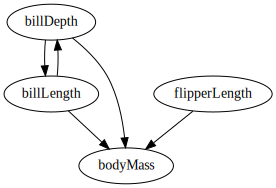

In [5]:
b_dag = gv.Digraph(name="Penguin Diagram")

b_dag.node('A','billDepth')
b_dag.node('B','billLength')
b_dag.node('C','flipperLength')
b_dag.node('D','bodyMass')

b_dag.edges(['AB','AD','BA','BD','CD'])
b_dag

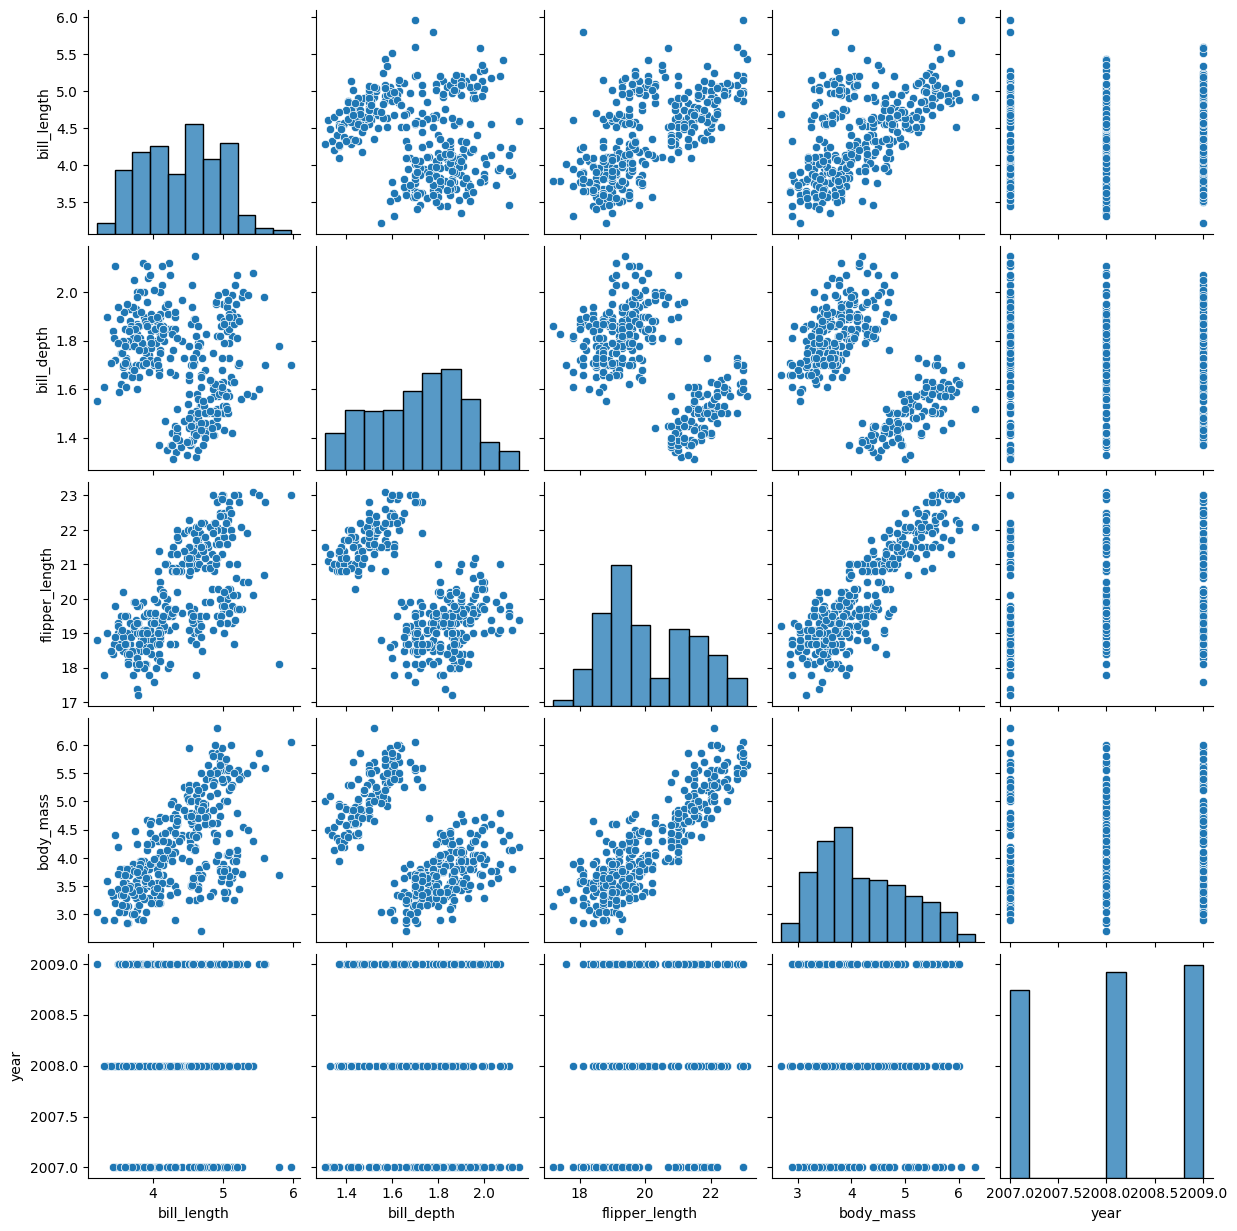

In [6]:
sns.pairplot(penguins)

In [7]:
#Combine all my estimator variables into one dataframe
X = penguins[[
             'bill_depth',
             'bill_length',
             'flipper_length',
             ]]
#Define my estimand as Y
Y = penguins['body_mass']

In [ ]:
with pm.Model() as model_penguins:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_penguins = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_penguins,model_penguins, extend_inferencedata=True)

(2.7, 6.3)

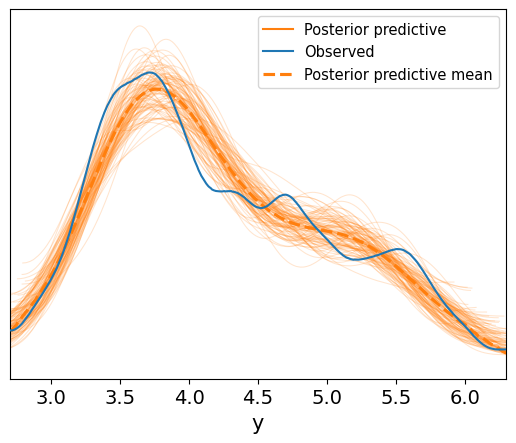

In [11]:
ax = az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])
ax.set_xlim(penguins['body_mass'].min(), penguins['body_mass'].max()) #used Gemini to get scale cause it wasn't displaying

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

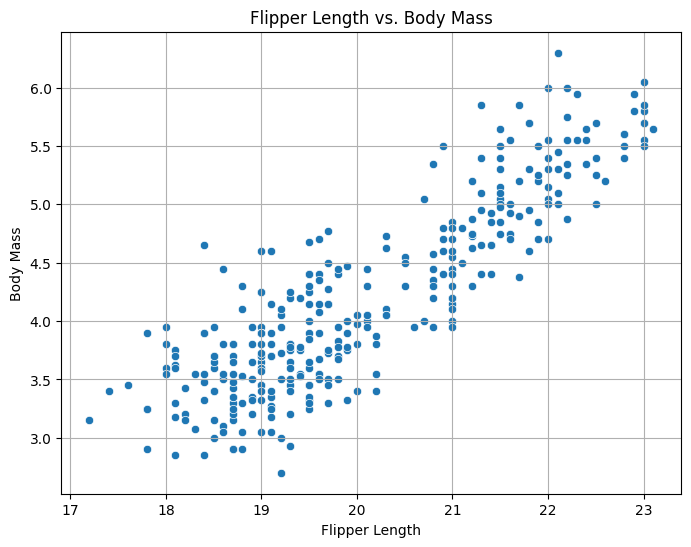

In [15]:
plt.figure(figsize=(8, 6))#gemini
sns.scatterplot(x='flipper_length', y='body_mass', data=penguins)
plt.title('Flipper Length vs. Body Mass')
plt.xlabel('Flipper Length')
plt.ylabel('Body Mass')
plt.grid(True)
plt.show()

In [13]:
posterior_mean = idata_penguins.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
    ).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


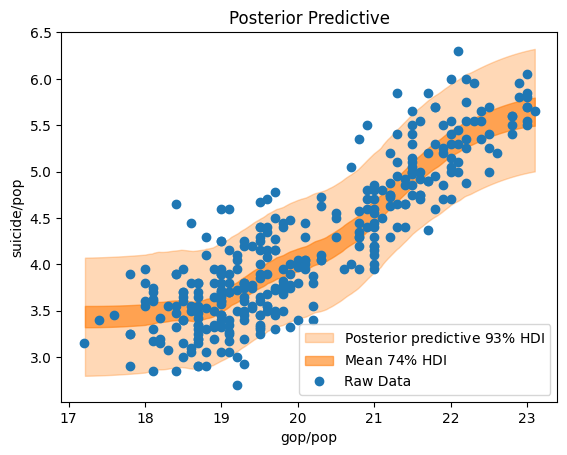

In [19]:
idx = np.argsort(X.to_numpy()[:, 2]) #gemini to know index
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 2],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 2],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(penguins['flipper_length'], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="gop/pop",
    ylabel="suicide/pop",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.
I don't think so because the posterior predictive seems to overfit the data as it follows the data super closely instead of showing the general trend.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='bill_depth'>, <Axes: xlabel='bill_length'>,
       <Axes: xlabel='flipper_length'>], dtype=object)

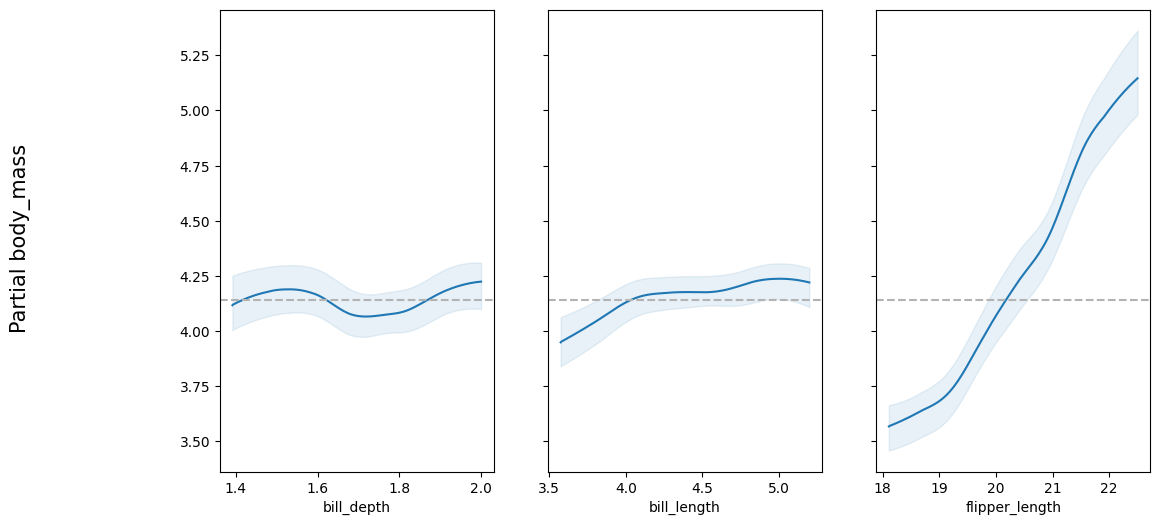

In [21]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 3), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='bill_depth'>, <Axes: xlabel='bill_length'>,
       <Axes: xlabel='flipper_length'>], dtype=object)

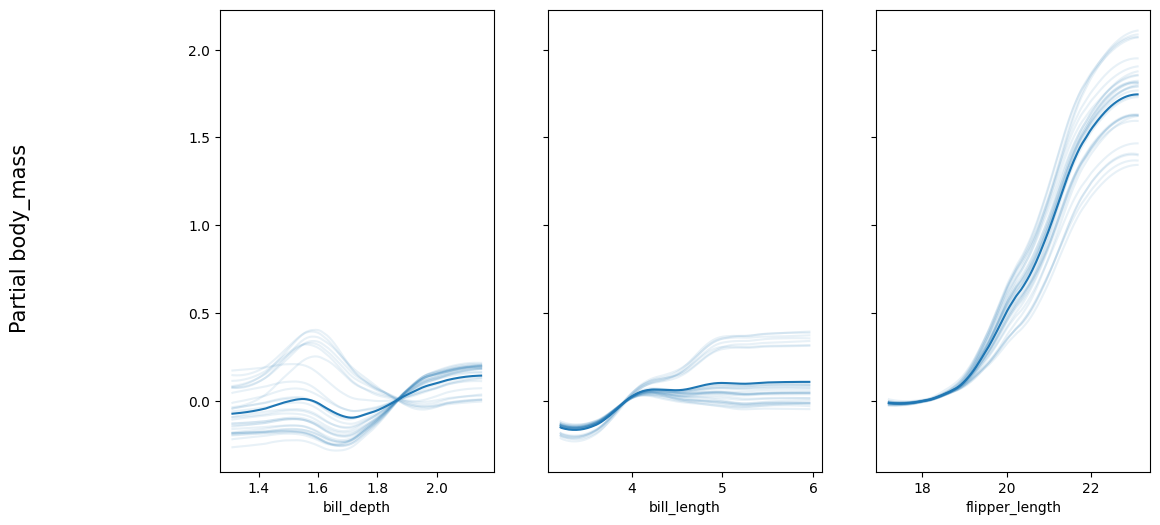

In [22]:
pmb.plot_ice( μ_, X, Y, grid=(1, 3), func=np.exp, figsize = (12,6))

In [25]:
vi_penguins = pmb.compute_variable_importance(idata_penguins, μ_, X, Y)

(0.85, 1.0)

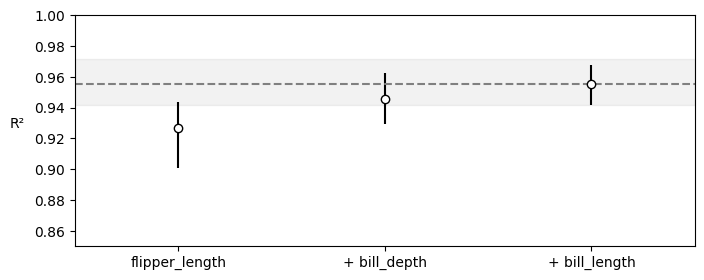

In [30]:
pmb.plot_variable_importance(vi_penguins).set_ylim(0.85,1.0)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?
I think all varibles have a positive correlation with body mass, with bill length and bill depth having a stronger correlation while flipper length has a weak one. This is seen in the vi graph, and can also be seen by pdp as the length and depth both follow the trend while flipper length has a steeper slope.

Is that relationship complicated by interactions between variables? How do you know?
I think that the relationship between depth and length with body mass is complicated by the fact that depth and length seem to have some correaltion. This can be seen in the pair plot and the pdp, vi, and ice as they both show that depth and length are similar to eachother.

Make sure to reference specific things you see in each plot, to justify your decisions and comments.